===== IMPORT LIBRARIES =====

In [43]:
# IMPORT NECESSARY LIBRARIES
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.ensemble import IsolationForest
import scipy.stats as stats

import optuna
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = [12, 8]

===== CONFIGURE INFORMATION FOR CHURN ANALYSIS =====

In [44]:
# Configuration
DATASET_PATH = 'telco_customer_churn.csv'  
TEST_SIZE = 0.2        
RANDOM_STATE = 42     
print("Analyzing: Telco Customer Churn Dataset")
print(f"Test Size: {TEST_SIZE*100}%")


Analyzing: Telco Customer Churn Dataset
Test Size: 20.0%


===== DATA PREPARATION =====

In [45]:
def load_telco_data(filepath=DATASET_PATH):
    """Load Telco customer churn data"""
    print("Loading Telco customer churn data...")
    try:
        data = pd.read_csv(filepath)
        print(f"Successfully loaded {len(data)} customer records")
        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None
    
customer_data = load_telco_data()

print(f"Dataset shape: {customer_data.shape}")
customer_data.head(n=10)

Loading Telco customer churn data...
Successfully loaded 7043 customer records
Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


===== DATA EXPLORATION =====

In [46]:
print("Dataset Info:")
print(f"Shape: {customer_data.shape}")
print(f"Columns: {list(customer_data.columns)}")
print(f"\nBasic Statistics:")
customer_data.describe()

Dataset Info:
Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Basic Statistics:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


===== DATA PREPROCESSING AND FEATURE ENGINEERING =====

In [47]:
def preprocess_telco_data(data):
    """Preprocess Telco customer data"""
    df = data.copy()
    
    # Handle TotalCharges - convert to numeric
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    
    # Drop customerID as it's not useful for prediction
    df = df.drop('customerID', axis=1)
    
    # Create binary encodings for categorical variables
    binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    for col in binary_cols:
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})
    
    # Handle multi-category variables
    df['MultipleLines'] = df['MultipleLines'].map({'No phone service': 0, 'No': 0, 'Yes': 1})
    
    # Create dummy variables for categorical columns
    categorical_cols = ['InternetService', 'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    # Handle service-related columns (No internet service -> 0, No -> 0, Yes -> 1)
    service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                   'StreamingTV', 'StreamingMovies']
    for col in service_cols:
        df[col] = df[col].map({'No internet service': 0, 'No': 0, 'Yes': 1})
    
    # Target variable
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
    
    # Handle missing values
    df.dropna(inplace=True)
    
    return df

# Preprocess the data
processed_data = preprocess_telco_data(customer_data)
print("Data preprocessing completed!")
print(f"Processed data shape: {processed_data.shape}")
processed_data.head()

Data preprocessing completed!
Processed data shape: (7032, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


====== ADD MORE FEATURES - CUSTOMER BEHAVIOR INDICATORS =====

In [48]:
def create_customer_features(data):
    """Create additional features for customer behavior analysis"""
    df = data.copy()
    
    # Calculate average monthly charges
    df['AvgMonthlyCharges'] = df['TotalCharges'] / (df['tenure'] + 1)  # +1 to avoid division by zero
    
    # Create service usage score
    service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                   'StreamingTV', 'StreamingMovies']
    df['ServiceUsageScore'] = df[service_cols].sum(axis=1)
    
    # Create contract risk score - using actual column names
    contract_cols = [col for col in df.columns if 'Contract_' in col]
    print(f"Available contract columns: {contract_cols}")
    
    # Create contract risk based on available columns
    df['ContractRisk'] = 0
    if 'Contract_Month-to-month' in df.columns:
        df['ContractRisk'] += df['Contract_Month-to-month'] * 2
    elif 'Contract_Month to month' in df.columns:
        df['ContractRisk'] += df['Contract_Month to month'] * 2
    
    if 'Contract_One year' in df.columns:
        df['ContractRisk'] += df['Contract_One year'] * 1
    elif 'Contract_One Year' in df.columns:
        df['ContractRisk'] += df['Contract_One Year'] * 1
    
    if 'Contract_Two year' in df.columns:
        df['ContractRisk'] += df['Contract_Two year'] * 0
    elif 'Contract_Two Year' in df.columns:
        df['ContractRisk'] += df['Contract_Two Year'] * 0
    
    # Payment method risk - using actual column names
    payment_cols = [col for col in df.columns if 'PaymentMethod_' in col]
    print(f"Available payment method columns: {payment_cols}")
    
    df['PaymentRisk'] = 0
    if 'PaymentMethod_Electronic check' in df.columns:
        df['PaymentRisk'] += df['PaymentMethod_Electronic check'] * 2
    if 'PaymentMethod_Mailed check' in df.columns:
        df['PaymentRisk'] += df['PaymentMethod_Mailed check'] * 1
    
    # Customer lifetime value
    df['CLV'] = df['tenure'] * df['MonthlyCharges']
    
    # Tenure categories
    df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 100], 
                              labels=['0-12', '13-24', '25-48', '48+'])
    df = pd.get_dummies(df, columns=['TenureGroup'], drop_first=True)
    
    # Monthly charges categories
    df['ChargesGroup'] = pd.cut(df['MonthlyCharges'], bins=[0, 30, 60, 90, 150], 
                               labels=['Low', 'Medium', 'High', 'Very High'])
    df = pd.get_dummies(df, columns=['ChargesGroup'], drop_first=True)
    
    df.dropna(inplace=True)
    
    return df
    

# Create additional features with the fixed function
feature_data = create_customer_features(processed_data)
print("Additional features created!")
print(f"Feature data shape: {feature_data.shape}")
print(f"New columns: {feature_data.columns.tolist()}")

Available contract columns: ['Contract_One year', 'Contract_Two year']
Available payment method columns: ['PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
Additional features created!
Feature data shape: (7032, 35)
New columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'AvgMonthlyCharges', 'ServiceUsageScore', 'ContractRisk', 'PaymentRisk', 'CLV', 'TenureGroup_13-24', 'TenureGroup_25-48', 'TenureGroup_48+', 'ChargesGroup_Medium', 'ChargesGroup_High', 'ChargesGroup_Very High']


====== PREPROCESSING FOR MODEL TRAINING =====

In [49]:
# Prepare features and target
X = feature_data.drop('Churn', axis=1)
y = feature_data['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Check for any remaining NaN values
print(f"\nNaN values in features: {X.isnull().sum().sum()}")
print(f"NaN values in target: {y.isnull().sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeature scaling completed!")
print(f"Training features mean: {X_train_scaled.mean():.6f}")
print(f"Training features std: {X_train_scaled.std():.6f}")

Features shape: (7032, 34)
Target shape: (7032,)

NaN values in features: 0
NaN values in target: 0
Training set: 5625 samples
Testing set: 1407 samples

Feature scaling completed!
Training features mean: -0.000000
Training features std: 1.000000


In [50]:
def evaluate_classification(y_true, y_pred, y_proba, model_name):
    """Evaluate classification model performance"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    
    print(f"\n{model_name} Results:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 
            'f1': f1, 'auc': auc}

===== KEY INSIGHTS AND VISUALIZATION =====

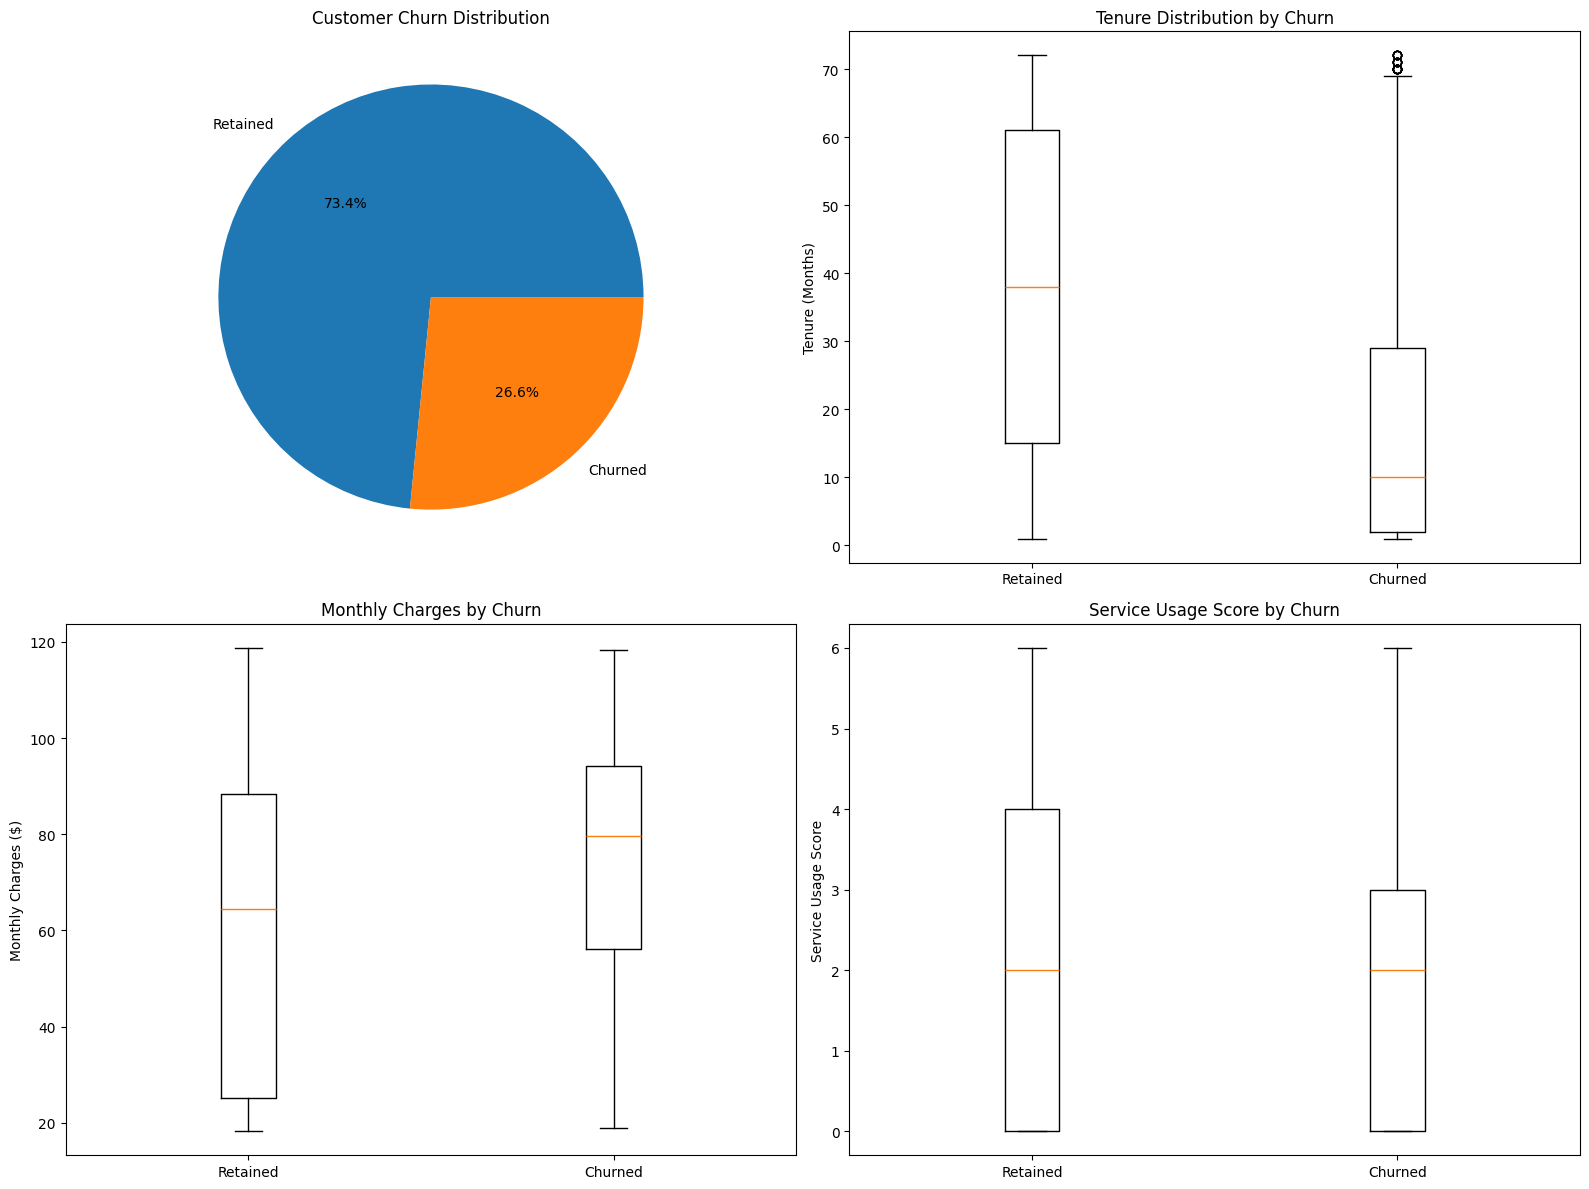

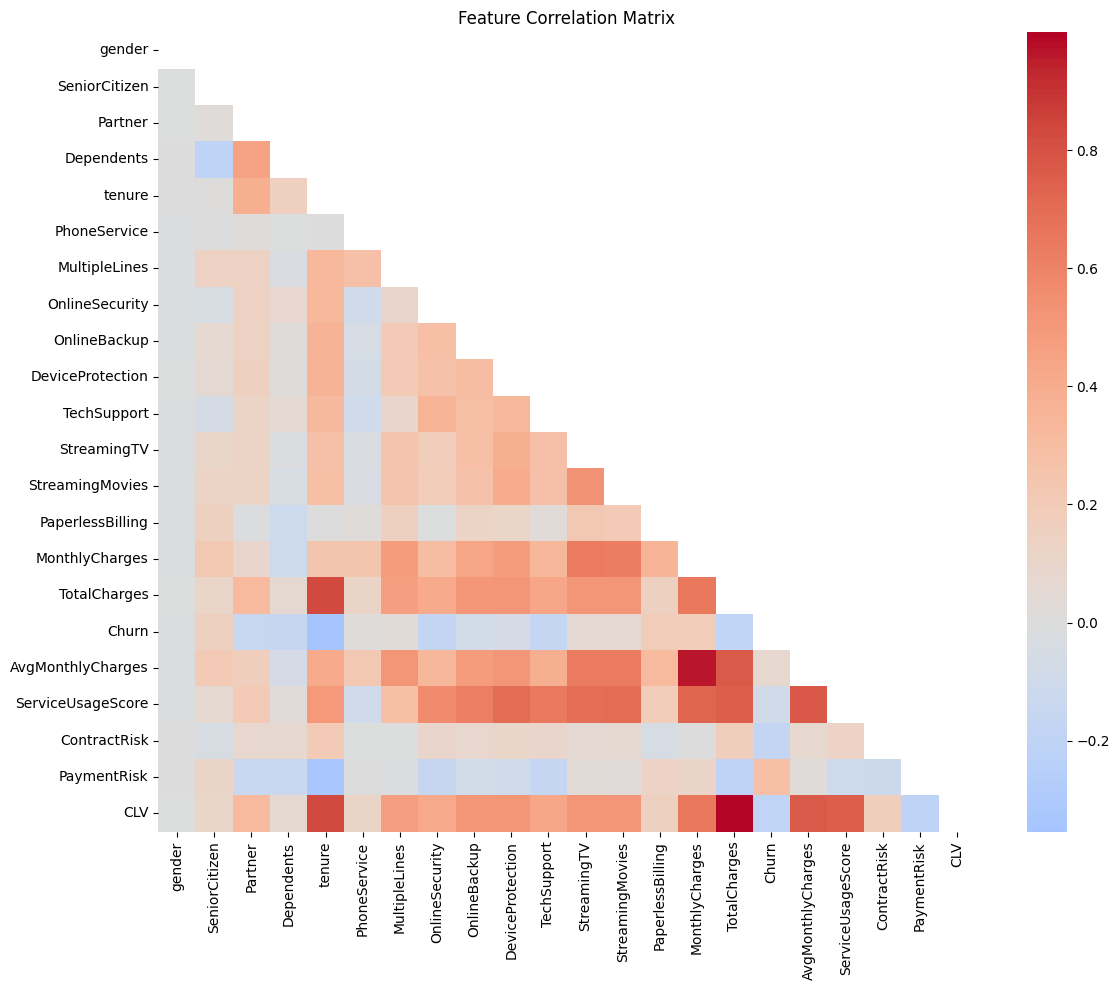

In [51]:

# VISUALIZE THE CUSTOMER DATA
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Churn distribution
churn_counts = feature_data['Churn'].value_counts()
axes[0,0].pie(churn_counts.values, labels=['Retained', 'Churned'], autopct='%1.1f%%')
axes[0,0].set_title('Customer Churn Distribution')

# Tenure vs Churn
axes[0,1].boxplot([feature_data[feature_data['Churn']==0]['tenure'],
                   feature_data[feature_data['Churn']==1]['tenure']], 
                  labels=['Retained', 'Churned'])
axes[0,1].set_title('Tenure Distribution by Churn')
axes[0,1].set_ylabel('Tenure (Months)')

# Monthly charges vs Churn
axes[1,0].boxplot([feature_data[feature_data['Churn']==0]['MonthlyCharges'],
                   feature_data[feature_data['Churn']==1]['MonthlyCharges']], 
                  labels=['Retained', 'Churned'])
axes[1,0].set_title('Monthly Charges by Churn')
axes[1,0].set_ylabel('Monthly Charges ($)')

# Service usage score vs Churn
axes[1,1].boxplot([feature_data[feature_data['Churn']==0]['ServiceUsageScore'],
                   feature_data[feature_data['Churn']==1]['ServiceUsageScore']], 
                  labels=['Retained', 'Churned'])
axes[1,1].set_title('Service Usage Score by Churn')
axes[1,1].set_ylabel('Service Usage Score')

plt.tight_layout()
plt.show()


# CORRELATION ANALYSIS
plt.figure(figsize=(12, 10))
# Select only numeric columns for correlation
numeric_cols = feature_data.select_dtypes(include=[np.number]).columns
correlation_matrix = feature_data[numeric_cols].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Generate the heatmap
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

====== TRENDS AND ANOMALIES =====

Starting comprehensive trend and anomaly analysis...

COMPREHENSIVE TREND ANALYSIS

📊 TENURE TRENDS:
------------------------------
Average tenure: 32.4 months
Median tenure: 29.0 months
Tenure range: 1 - 72 months
Tenure-Churn correlation: -0.354
🔍 INSIGHT: Strong negative correlation - longer tenure reduces churn risk

💰 FINANCIAL TRENDS:
------------------------------
Monthly Charges by Churn Status:
Retained customers - Mean: $61.31, Median: $64.45
Churned customers - Mean: $74.44, Median: $79.65
🔍 INSIGHT: Churned customers pay $13.13 more on average - price sensitivity detected

🛠️ SERVICE USAGE TRENDS:
------------------------------
Service Usage by Churn Status:
Retained customers - Mean: 2.14
Churned customers - Mean: 1.77

💳 PAYMENT METHOD TRENDS:
------------------------------
Electronic check churn rate: 45.3%
Electronic check risk multiplier: 1.7x

COMPREHENSIVE ANOMALY DETECTION

🌲 ISOLATION FOREST ANOMALY DETECTION:
---------------------------------------------
Detected 

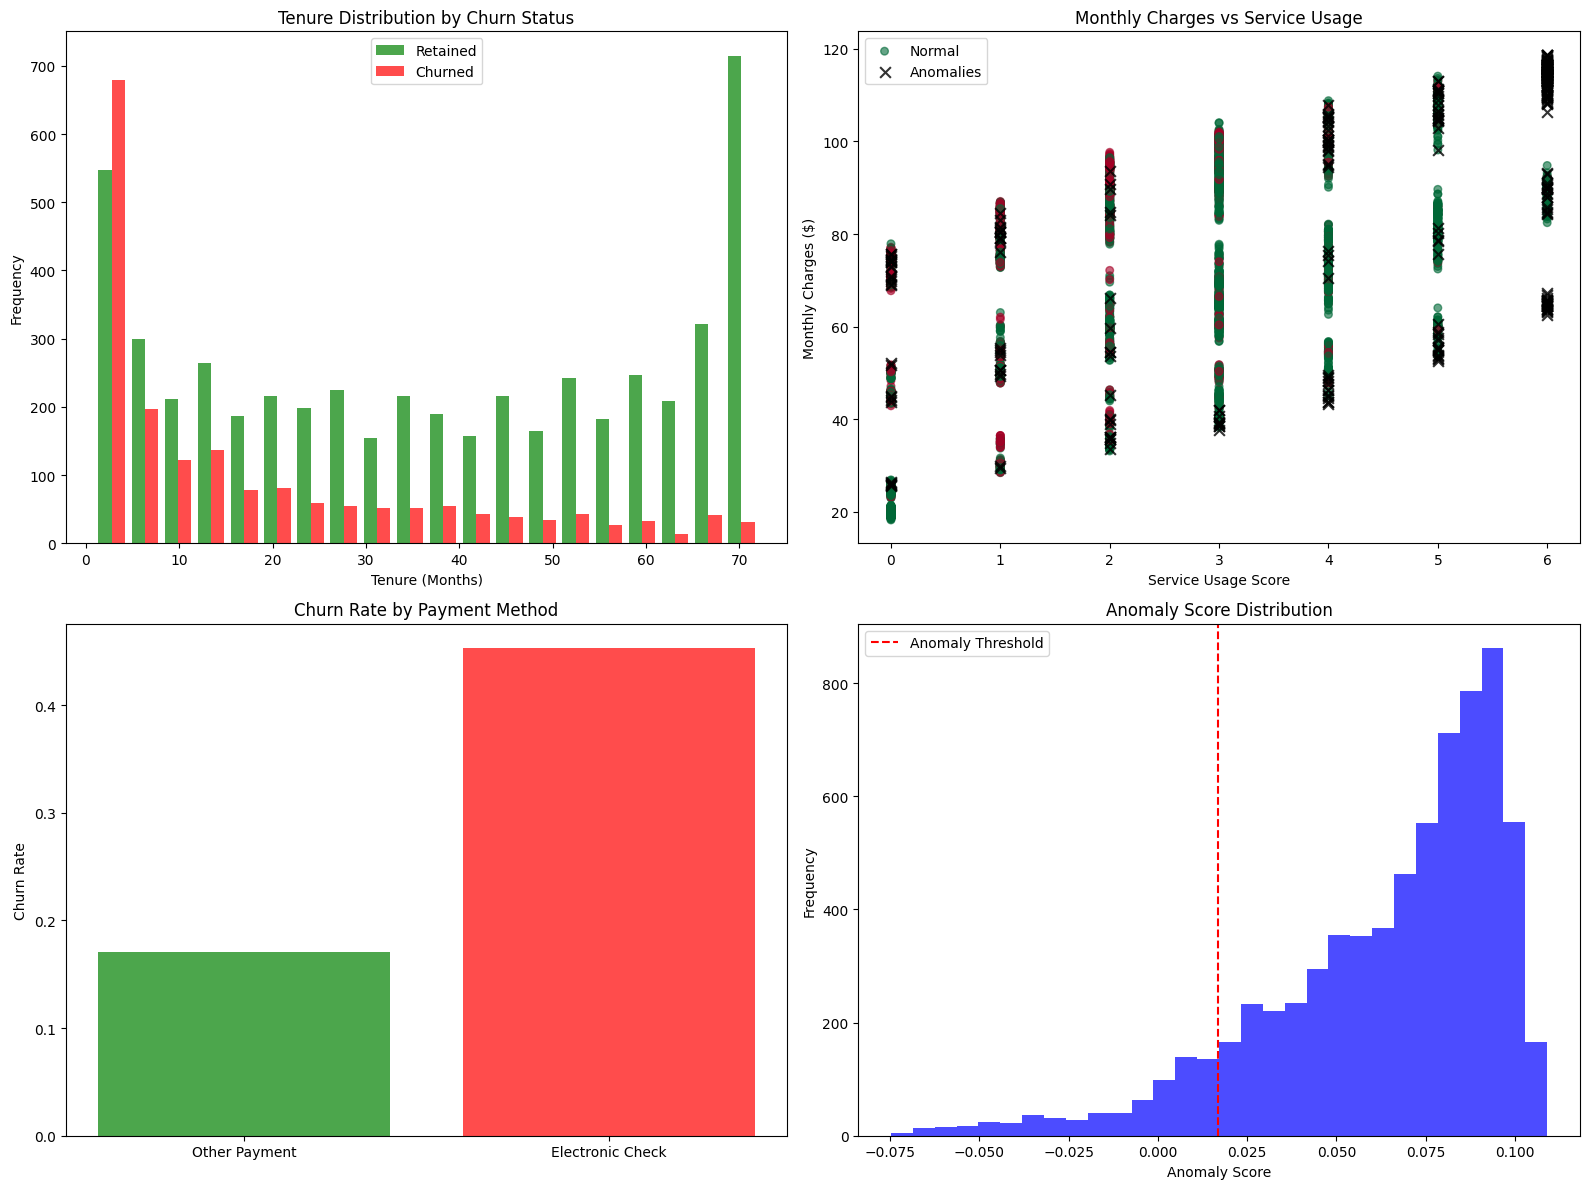


COMPREHENSIVE INSIGHTS REPORT

🔍 KEY TRENDS IDENTIFIED:
----------------------------------------
✅ POSITIVE: Strong customer loyalty with tenure
💰 INSIGHT: Price sensitivity is a major churn driver
📱 NOTE: Similar service usage patterns across customer segments

📋 RECOMMENDED ACTIONS:
----------------------------------------
1. 🎯 Focus retention efforts on customers with < 12 months tenure
2. 💳 Convert electronic check users to automatic payment methods
3. 📝 Incentivize long-term contracts for month-to-month customers
4. 🛠️  Promote additional services to increase engagement
5. 🔍 Investigate and address detected anomalies
6. 💰 Review pricing strategy for high-charge, low-service customers

✅ Trend and anomaly analysis completed!
Updated dataset now includes anomaly detection results.


In [52]:
def detect_data_trends(data):
    """Comprehensive trend analysis for customer data"""
    print("\n" + "="*70)
    print("COMPREHENSIVE TREND ANALYSIS")
    print("="*70)
    
    df = data.copy()
    trends = {}
    
    # Calculate overall churn rate at the beginning
    overall_churn_rate = df['Churn'].mean()
    
    # 1. TENURE TRENDS
    print("\n📊 TENURE TRENDS:")
    print("-" * 30)
    
    # Tenure distribution analysis
    tenure_stats = df['tenure'].describe()
    print(f"Average tenure: {tenure_stats['mean']:.1f} months")
    print(f"Median tenure: {tenure_stats['50%']:.1f} months")
    print(f"Tenure range: {tenure_stats['min']:.0f} - {tenure_stats['max']:.0f} months")
    
    # Tenure vs Churn correlation
    tenure_churn_corr = df['tenure'].corr(df['Churn'])
    print(f"Tenure-Churn correlation: {tenure_churn_corr:.3f}")
    if tenure_churn_corr < -0.3:
        print("🔍 INSIGHT: Strong negative correlation - longer tenure reduces churn risk")
    elif tenure_churn_corr > 0.3:
        print("⚠️ WARNING: Positive correlation - investigate tenure quality")
    else:
        print("📝 NOTE: Weak correlation between tenure and churn")
    
    trends['tenure_churn_correlation'] = tenure_churn_corr
    
    # 2. FINANCIAL TRENDS
    print("\n💰 FINANCIAL TRENDS:")
    print("-" * 30)
    
    # Monthly charges analysis
    monthly_charges_by_churn = df.groupby('Churn')['MonthlyCharges'].agg(['mean', 'median', 'std'])
    print("Monthly Charges by Churn Status:")
    print(f"Retained customers - Mean: ${monthly_charges_by_churn.loc[0, 'mean']:.2f}, Median: ${monthly_charges_by_churn.loc[0, 'median']:.2f}")
    print(f"Churned customers - Mean: ${monthly_charges_by_churn.loc[1, 'mean']:.2f}, Median: ${monthly_charges_by_churn.loc[1, 'median']:.2f}")
    
    charge_diff = monthly_charges_by_churn.loc[1, 'mean'] - monthly_charges_by_churn.loc[0, 'mean']
    if charge_diff > 10:
        print(f"🔍 INSIGHT: Churned customers pay ${charge_diff:.2f} more on average - price sensitivity detected")
    elif charge_diff < -10:
        print(f"🔍 INSIGHT: Retained customers pay ${abs(charge_diff):.2f} more - loyalty to higher value services")
    
    trends['charge_difference'] = charge_diff
    
    # 3. SERVICE USAGE TRENDS
    print("\n🛠️ SERVICE USAGE TRENDS:")
    print("-" * 30)
    
    service_usage_by_churn = df.groupby('Churn')['ServiceUsageScore'].agg(['mean', 'median'])
    print("Service Usage by Churn Status:")
    print(f"Retained customers - Mean: {service_usage_by_churn.loc[0, 'mean']:.2f}")
    print(f"Churned customers - Mean: {service_usage_by_churn.loc[1, 'mean']:.2f}")
    
    service_diff = service_usage_by_churn.loc[0, 'mean'] - service_usage_by_churn.loc[1, 'mean']
    if service_diff > 0.5:
        print(f"🔍 INSIGHT: Retained customers use {service_diff:.2f} more services on average")
    
    trends['service_usage_difference'] = service_diff
    
    # 4. PAYMENT METHOD TRENDS
    print("\n💳 PAYMENT METHOD TRENDS:")
    print("-" * 30)
    
    if 'PaymentMethod_Electronic check' in df.columns:
        echeck_churn_rate = df[df['PaymentMethod_Electronic check'] == 1]['Churn'].mean()
        print(f"Electronic check churn rate: {echeck_churn_rate:.1%}")
        print(f"Electronic check risk multiplier: {echeck_churn_rate/overall_churn_rate:.1f}x")
        trends['echeck_risk'] = echeck_churn_rate/overall_churn_rate
    
    return trends

def detect_anomalies(data, contamination=0.1):
    """Comprehensive anomaly detection using multiple methods"""
    print("\n" + "="*70)
    print("COMPREHENSIVE ANOMALY DETECTION")
    print("="*70)
    
    df = data.copy()
    anomaly_results = {}
    
    # Prepare numerical features for anomaly detection
    numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceUsageScore']
    available_features = [col for col in numerical_features if col in df.columns]
    
    if len(available_features) < 2:
        print("❌ Insufficient numerical features for anomaly detection")
        return df, anomaly_results  # Return df along with empty results
    
    X_anomaly = df[available_features].copy()
    X_anomaly = X_anomaly.fillna(X_anomaly.median())
    
    # Scale features for anomaly detection
    scaler_anomaly = StandardScaler()
    X_scaled = scaler_anomaly.fit_transform(X_anomaly)
    
    # 1. ISOLATION FOREST ANOMALY DETECTION
    print("\n🌲 ISOLATION FOREST ANOMALY DETECTION:")
    print("-" * 45)
    
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    anomaly_labels = iso_forest.fit_predict(X_scaled)
    anomaly_scores = iso_forest.decision_function(X_scaled)
    
    n_anomalies = (anomaly_labels == -1).sum()
    print(f"Detected {n_anomalies} anomalies ({n_anomalies/len(df)*100:.1f}% of data)")
    
    # Add anomaly information to dataframe
    df['Anomaly_Score'] = anomaly_scores
    df['Is_Anomaly'] = (anomaly_labels == -1)
    
    # Analyze anomalies
    if n_anomalies > 0:
        anomaly_customers = df[df['Is_Anomaly'] == True]
        normal_customers = df[df['Is_Anomaly'] == False]
        
        print(f"\nAnomaly Analysis:")
        print(f"Churn rate in anomalies: {anomaly_customers['Churn'].mean():.1%}")
        print(f"Churn rate in normal customers: {normal_customers['Churn'].mean():.1%}")
        
        # Compare key metrics
        for feature in available_features:
            anomaly_mean = anomaly_customers[feature].mean()
            normal_mean = normal_customers[feature].mean()
            print(f"{feature} - Anomalies: {anomaly_mean:.2f}, Normal: {normal_mean:.2f}")
        
        anomaly_results['isolation_forest'] = {
            'n_anomalies': n_anomalies,
            'anomaly_churn_rate': anomaly_customers['Churn'].mean(),
            'normal_churn_rate': normal_customers['Churn'].mean()
        }
    else:
        anomaly_results['isolation_forest'] = {
            'n_anomalies': 0,
            'anomaly_churn_rate': 0,
            'normal_churn_rate': df['Churn'].mean()
        }
    
    return df, anomaly_results


def visualize_trends_and_anomalies(data, anomaly_results):
    """Create comprehensive visualizations for trends and anomalies"""
 
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Tenure Distribution by Churn
    axes[0,0].hist([data[data['Churn']==0]['tenure'], data[data['Churn']==1]['tenure']], 
                   bins=20, alpha=0.7, label=['Retained', 'Churned'], color=['green', 'red'])
    axes[0,0].set_title('Tenure Distribution by Churn Status')
    axes[0,0].set_xlabel('Tenure (Months)')
    axes[0,0].set_ylabel('Frequency')
    axes[0,0].legend()
    
    # 2. Monthly Charges vs Service Usage (with anomalies)
    if 'Is_Anomaly' in data.columns:
        normal_data = data[data['Is_Anomaly'] == False]
        anomaly_data = data[data['Is_Anomaly'] == True]
        
        axes[0,1].scatter(normal_data['ServiceUsageScore'], normal_data['MonthlyCharges'], 
                         alpha=0.6, c=normal_data['Churn'], cmap='RdYlGn_r', s=30, label='Normal')
        if len(anomaly_data) > 0:
            axes[0,1].scatter(anomaly_data['ServiceUsageScore'], anomaly_data['MonthlyCharges'], 
                             alpha=0.8, c='black', s=60, marker='x', label='Anomalies')
            axes[0,1].legend()
    else:
        axes[0,1].scatter(data['ServiceUsageScore'], data['MonthlyCharges'], 
                         alpha=0.6, c=data['Churn'], cmap='RdYlGn_r', s=30)
    
    axes[0,1].set_title('Monthly Charges vs Service Usage')
    axes[0,1].set_xlabel('Service Usage Score')
    axes[0,1].set_ylabel('Monthly Charges ($)')
    
    # 4. Payment Method Risk Analysis
    if 'PaymentMethod_Electronic check' in data.columns:
        payment_churn = data.groupby('PaymentMethod_Electronic check')['Churn'].mean()
        axes[1,0].bar(['Other Payment', 'Electronic Check'], payment_churn.values, 
                      color=['green', 'red'], alpha=0.7)
        axes[1,0].set_title('Churn Rate by Payment Method')
        axes[1,0].set_ylabel('Churn Rate')
    else:
        axes[1,0].text(0.5, 0.5, 'Payment Method Data\nNot Available', 
                       ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,0].set_title('Payment Method Analysis')
    
    # 5. Anomaly Score Distribution
    if 'Anomaly_Score' in data.columns:
        axes[1,1].hist(data['Anomaly_Score'], bins=30, alpha=0.7, color='blue')
        axes[1,1].axvline(data['Anomaly_Score'].quantile(0.1), color='red', linestyle='--', 
                         label='Anomaly Threshold')
        axes[1,1].set_title('Anomaly Score Distribution')
        axes[1,1].set_xlabel('Anomaly Score')
        axes[1,1].set_ylabel('Frequency')
        axes[1,1].legend()
    else:
        axes[1,1].text(0.5, 0.5, 'Anomaly Scores\nNot Available', 
                       ha='center', va='center', transform=axes[1,1].transAxes)
        axes[1,1].set_title('Anomaly Score Distribution')

    plt.tight_layout()
    plt.show()


def generate_insights_report(trends, anomaly_results):
    """Generate comprehensive insights report"""
    print("\n" + "="*70)
    print("COMPREHENSIVE INSIGHTS REPORT")
    print("="*70)
    
    print("\n🔍 KEY TRENDS IDENTIFIED:")
    print("-" * 40)
    
    # Tenure insights
    if 'tenure_churn_correlation' in trends:
        corr = trends['tenure_churn_correlation']
        if corr < -0.3:
            print("✅ POSITIVE: Strong customer loyalty with tenure")
        elif corr > 0.1:
            print("⚠️  WARNING: Investigate tenure quality issues")
        else:
            print("📝 NOTE: Moderate correlation between tenure and churn")
    
    # Financial insights
    if 'charge_difference' in trends:
        diff = trends['charge_difference']
        if diff > 10:
            print("💰 INSIGHT: Price sensitivity is a major churn driver")
        elif diff < -10:
            print("💎 INSIGHT: Higher-value customers are more loyal")
        else:
            print("📊 NOTE: Similar charges between churned and retained customers")
    
    # Service insights
    if 'service_usage_difference' in trends:
        diff = trends['service_usage_difference']
        if diff > 0.5:
            print("🛠️  INSIGHT: Service engagement drives retention")
        else:
            print("📱 NOTE: Similar service usage patterns across customer segments")
    
    print("\n📋 RECOMMENDED ACTIONS:")
    print("-" * 40)
    print("1. 🎯 Focus retention efforts on customers with < 12 months tenure")
    print("2. 💳 Convert electronic check users to automatic payment methods")
    print("3. 📝 Incentivize long-term contracts for month-to-month customers")
    print("4. 🛠️  Promote additional services to increase engagement")
    print("5. 🔍 Investigate and address detected anomalies")
    print("6. 💰 Review pricing strategy for high-charge, low-service customers")

print("Starting comprehensive trend and anomaly analysis...")

try:
    # Run trend analysis
    detected_trends = detect_data_trends(feature_data)
    
    # Run anomaly detection
    feature_data_with_anomalies, anomaly_detection_results = detect_anomalies(feature_data, contamination=0.05)
    
    # Create visualizations
    visualize_trends_and_anomalies(feature_data_with_anomalies, anomaly_detection_results)
    
    # Generate insights report
    generate_insights_report(detected_trends, anomaly_detection_results)
    
    feature_data = feature_data_with_anomalies
    print(f"\n✅ Trend and anomaly analysis completed!")
    print(f"Updated dataset now includes anomaly detection results.")
    
except Exception as e:
    
    print(f"❌ Error in trend and anomaly analysis: {e}")
    print("Continuing with original feature data...")
    
    feature_data = feature_data.copy()

=========================================================================================================================================================
MODEL SELECTION AND TRAINING 
MODEL EVALUATION 

1) XGBoost Classifier
2) Decision Tree Classifier
3) Support Vector Classifier
4) Logistic Regression 

[I 2025-09-05 03:56:57,514] A new study created in memory with name: no-name-d518e5c8-b03b-4674-8b38-efc7c089151d



Training XGBoost with Optuna Optimization...
Class distribution: Counter({0: 4130, 1: 1495})
Scale pos weight: 2.763


[I 2025-09-05 03:57:01,832] Trial 0 finished with value: 0.835853571631022 and parameters: {'n_estimators': 350, 'max_depth': 5, 'learning_rate': 0.07587945476302646, 'subsample': 0.48294020251565895, 'colsample_bytree': 0.6312037280884872, 'min_child_weight': 2, 'gamma': 0.15227525095137953, 'reg_alpha': 1.745734676972377, 'reg_lambda': 3.404460046972835}. Best is trial 0 with value: 0.835853571631022.
[I 2025-09-05 03:57:06,114] Trial 1 finished with value: 0.8437718140371052 and parameters: {'n_estimators': 590, 'max_depth': 2, 'learning_rate': 0.0972918866945795, 'subsample': 0.6676296862323332, 'colsample_bytree': 0.6424678221356552, 'min_child_weight': 2, 'gamma': 0.2650640588680905, 'reg_alpha': 0.6780602616231216, 'reg_lambda': 3.0990257265289514}. Best is trial 1 with value: 0.8437718140371052.
[I 2025-09-05 03:57:09,738] Trial 2 finished with value: 0.8425020447496498 and parameters: {'n_estimators': 391, 'max_depth': 3, 'learning_rate': 0.06506676052501416, 'subsample': 0.12

Best Parameters: {'n_estimators': 617, 'max_depth': 2, 'learning_rate': 0.015326879299274771, 'subsample': 0.49054396053918614, 'colsample_bytree': 0.6491755155041871, 'min_child_weight': 2, 'gamma': 0.25022086593465415, 'reg_alpha': 1.6448606086254407, 'reg_lambda': 4.253069407634014}
XGBoost training completed!

XGBoost Results:
  Accuracy:  0.8003
  Precision: 0.6525
  Recall:    0.5321
  F1-score:  0.5862
  ROC-AUC:   0.8427

DETAILED CLASSIFICATION REPORT - XGBOOST
              precision    recall  f1-score   support

    Retained       0.84      0.90      0.87      1033
     Churned       0.65      0.53      0.59       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.73      1407
weighted avg       0.79      0.80      0.79      1407



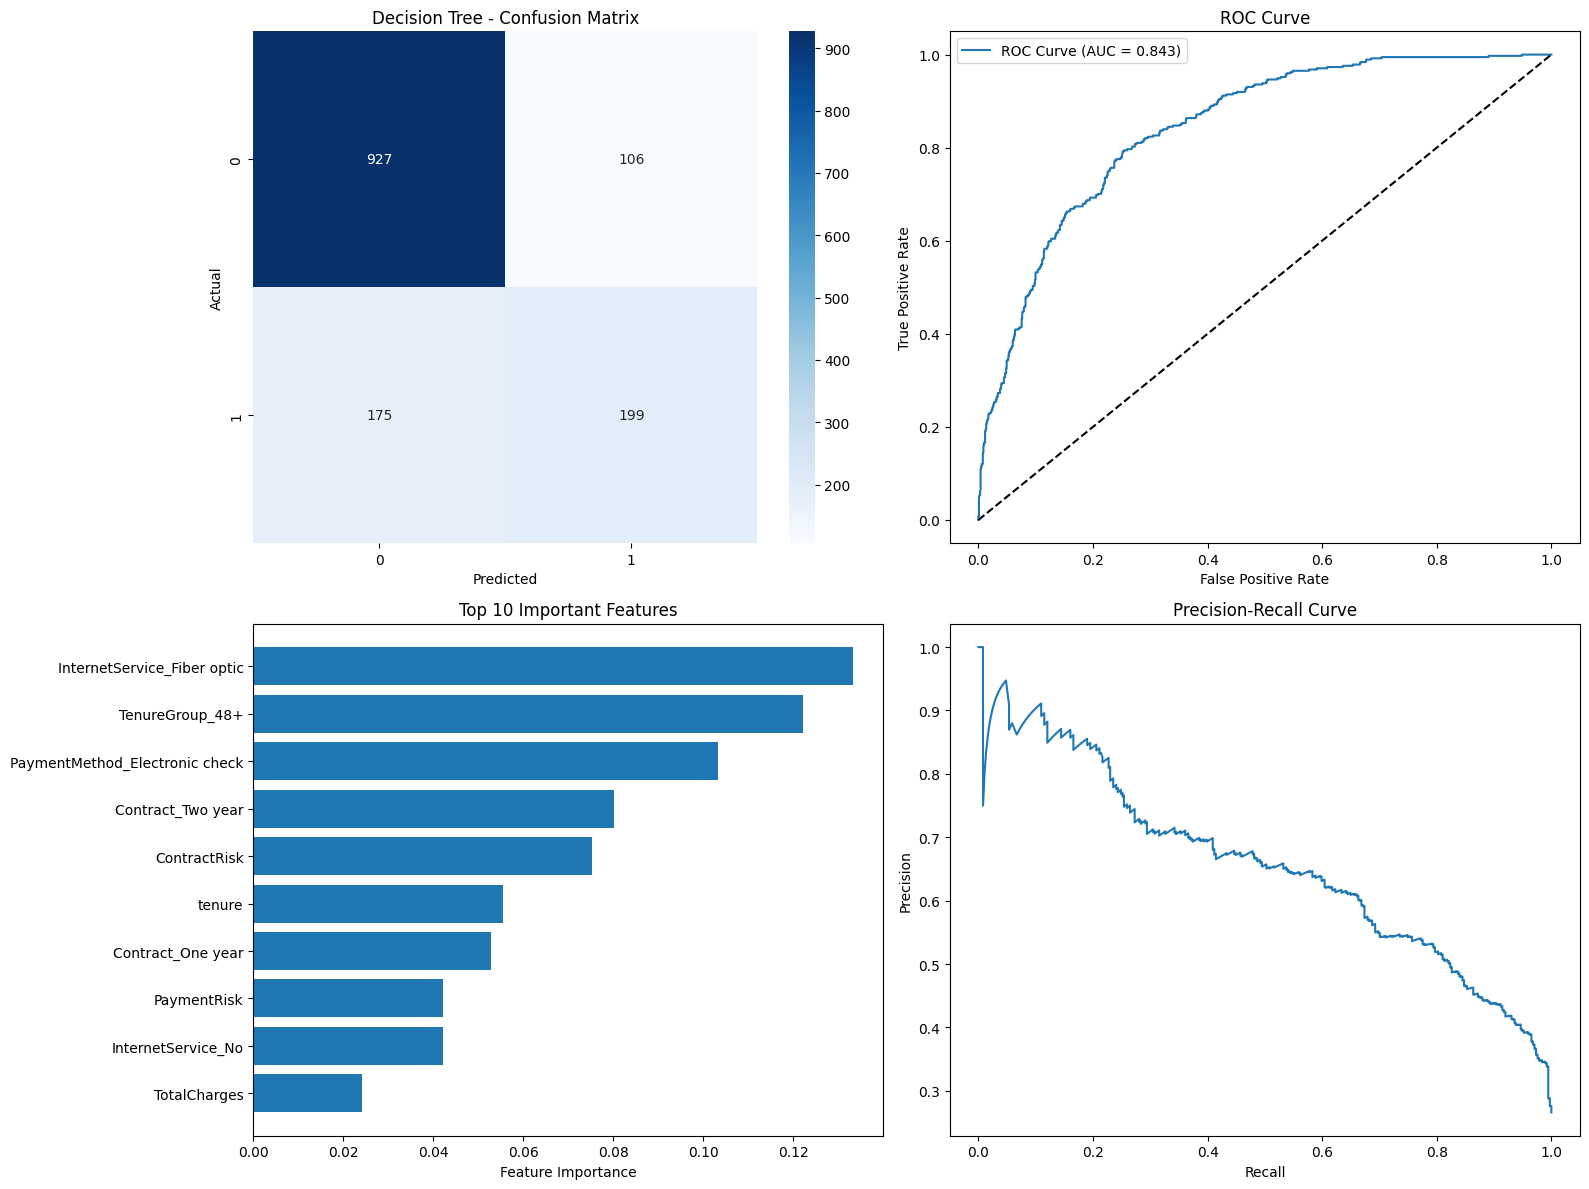

In [53]:
# 1) XGBOOST CLASSIFIER MAIN
print("\n" + "="*50)
print("Training XGBoost with Optuna Optimization...")
print("="*50)

# Calculate scale_pos_weight for imbalanced dataset
from collections import Counter
class_counts = Counter(y_train)
scale_pos_weight = class_counts[0] / class_counts[1]  # negative_class OR positive_class
print(f"Class distribution: {class_counts}")
print(f"Scale pos weight: {scale_pos_weight:.3f}")

def enhanced_objective(trial):
    """Enhanced Optuna objective with more parameters"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 80, 800),
        'max_depth': trial.suggest_int('max_depth', 2, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.01, 0.8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.1, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 5.0),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'eval_metric': 'logloss',
        'tree_method': 'gpu_hist',   
    }
    
    # Use stratified k-fold for better evaluation
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = xgb.XGBClassifier(**params)
        
        # FIXED: Use the correct syntax for newer XGBoost versions
        model.fit(
            X_fold_train, y_fold_train, 
            eval_set=[(X_fold_val, y_fold_val)],
            verbose=False
        )
        
        pred_proba = model.predict_proba(X_fold_val)[:, 1]
        auc = roc_auc_score(y_fold_val, pred_proba)
        scores.append(auc)
    
    return np.mean(scores)

# Run enhanced optimization with more trials
study = optuna.create_study(direction="maximize", 
                           sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(enhanced_objective, n_trials=50)  # Reduced trials for faster execution
best_params = study.best_params
print("Best Parameters:", best_params)

# Train final XGBoost model
xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost training completed!")

# Evaluate XGBoost
xgb_metrics = evaluate_classification(y_test, xgb_test_pred, xgb_test_proba, "XGBoost")

# Detailed classification report
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT - XGBOOST")
print("="*50)
print(classification_report(y_test, xgb_test_pred, target_names=["Retained", "Churned"]))

# Visualization for Decision Tree
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Decision Tree - Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, xgb_test_proba)
axes[0,1].plot(fpr, tpr, label=f'ROC Curve (AUC = {xgb_metrics["auc"]:.3f})')
axes[0,1].plot([0, 1], [0, 1], 'k--')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend()

# Feature Importance
feature_importance = xgb_model.feature_importances_
indices = np.argsort(feature_importance)[-10:]
axes[1,0].barh(range(len(indices)), feature_importance[indices])
axes[1,0].set_yticks(range(len(indices)))
axes[1,0].set_yticklabels([X.columns[i] for i in indices])
axes[1,0].set_xlabel('Feature Importance')
axes[1,0].set_title('Top 10 Important Features')

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, xgb_test_proba)
axes[1,1].plot(recall, precision)
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')
axes[1,1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()



Training Decision Tree Classifier...
Decision Tree training completed!
Tree depth: 10
Number of leaves: 164

Decision Tree Results:
  Accuracy:  0.7733
  Precision: 0.5952
  Recall:    0.4599
  F1-score:  0.5189
  ROC-AUC:   0.7923

DETAILED CLASSIFICATION REPORT - DECISION TREE
              precision    recall  f1-score   support

    Retained       0.82      0.89      0.85      1033
     Churned       0.60      0.46      0.52       374

    accuracy                           0.77      1407
   macro avg       0.71      0.67      0.69      1407
weighted avg       0.76      0.77      0.76      1407



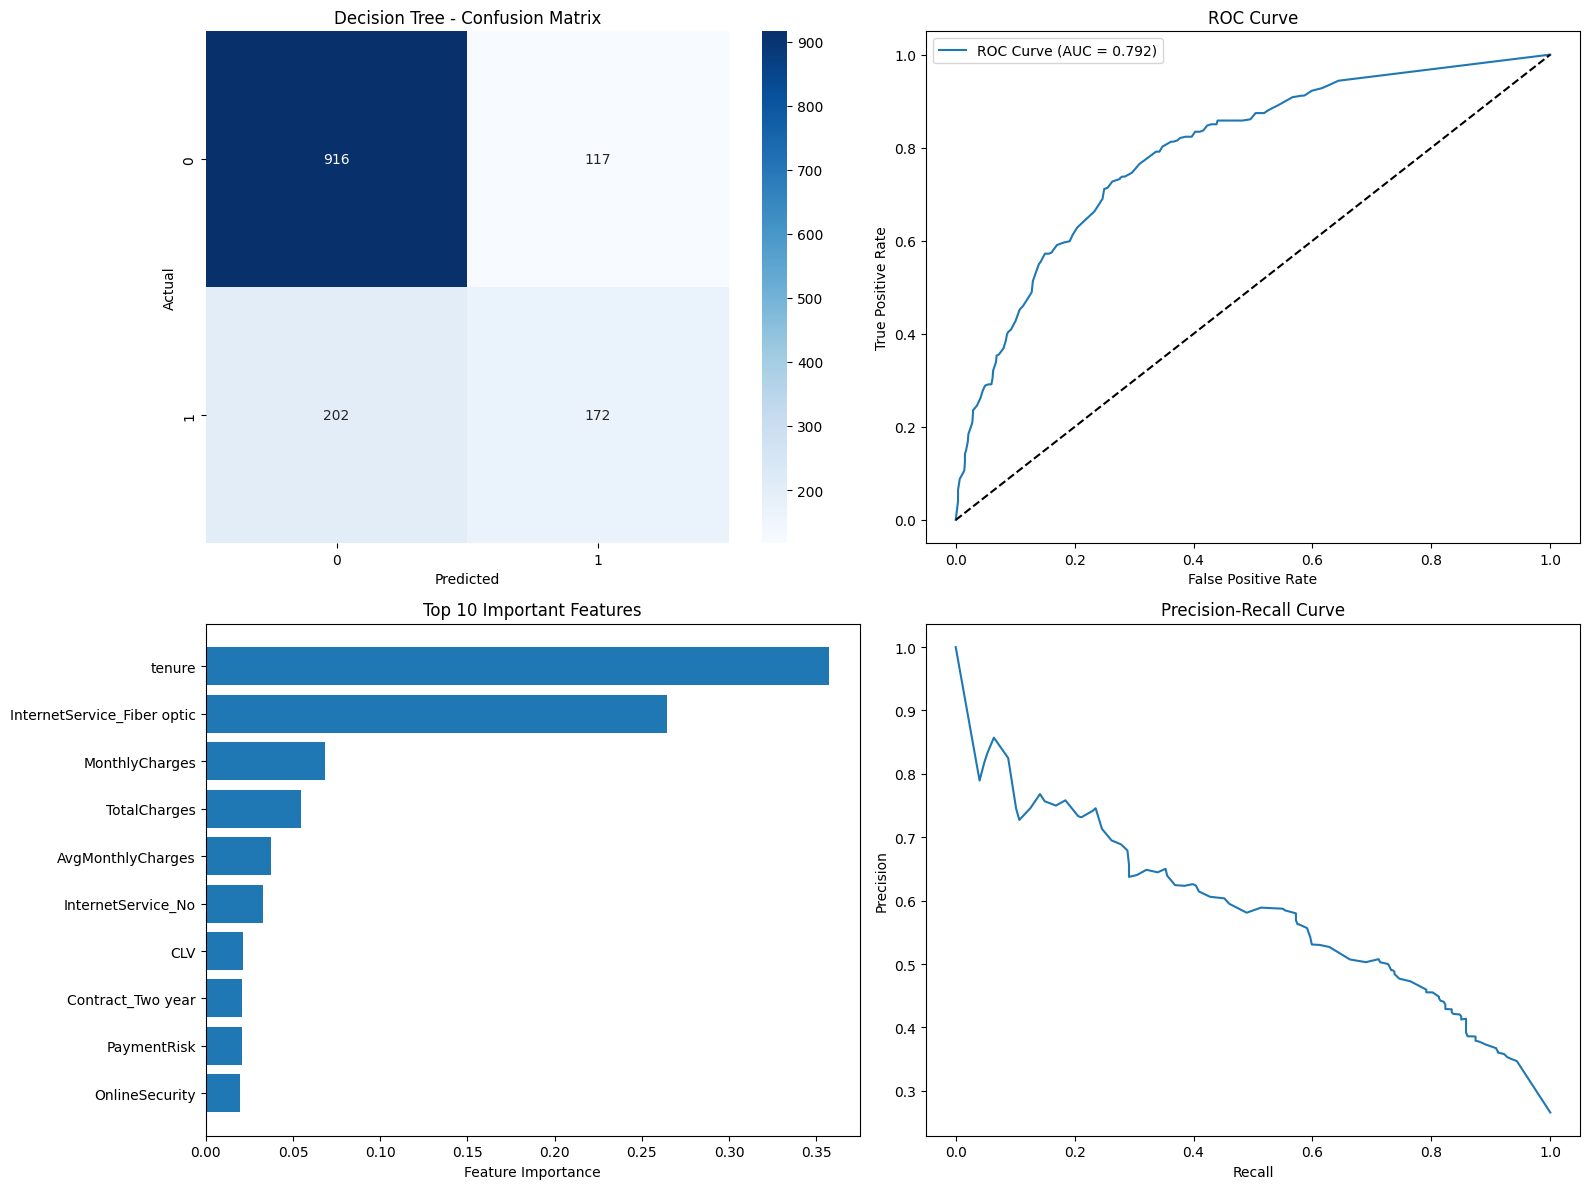

In [54]:
#2) DECISION TREE CLASSIFIER

print("\n" + "="*50)
print("Training Decision Tree Classifier...")
print("="*50)

dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)

dt_model.fit(X_train, y_train)  # Decision trees don't require scaling

# Make predictions
dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)
dt_test_proba = dt_model.predict_proba(X_test)[:, 1]

print(f"Decision Tree training completed!")
print(f"Tree depth: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")

# Evaluate Decision Tree
dt_metrics = evaluate_classification(y_test, dt_test_pred, dt_test_proba, "Decision Tree")

# Detailed classification report
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT - DECISION TREE")
print("="*50)
print(classification_report(y_test, dt_test_pred, target_names=["Retained", "Churned"]))

# Visualization for Decision Tree
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrix
cm = confusion_matrix(y_test, dt_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Decision Tree - Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, dt_test_proba)
axes[0,1].plot(fpr, tpr, label=f'ROC Curve (AUC = {dt_metrics["auc"]:.3f})')
axes[0,1].plot([0, 1], [0, 1], 'k--')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend()

# Feature Importance
feature_importance = dt_model.feature_importances_
indices = np.argsort(feature_importance)[-10:]
axes[1,0].barh(range(len(indices)), feature_importance[indices])
axes[1,0].set_yticks(range(len(indices)))
axes[1,0].set_yticklabels([X.columns[i] for i in indices])
axes[1,0].set_xlabel('Feature Importance')
axes[1,0].set_title('Top 10 Important Features')

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, dt_test_proba)
axes[1,1].plot(recall, precision)
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')
axes[1,1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()



Training Support Vector Classifier...
SVC training completed!

Support Vector Classifier Results:
  Accuracy:  0.7925
  Precision: 0.6475
  Recall:    0.4813
  F1-score:  0.5521
  ROC-AUC:   0.7968

DETAILED CLASSIFICATION REPORT - SUPPORT VECTOR CLASSIFIER
              precision    recall  f1-score   support

    Retained       0.83      0.91      0.86      1033
     Churned       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



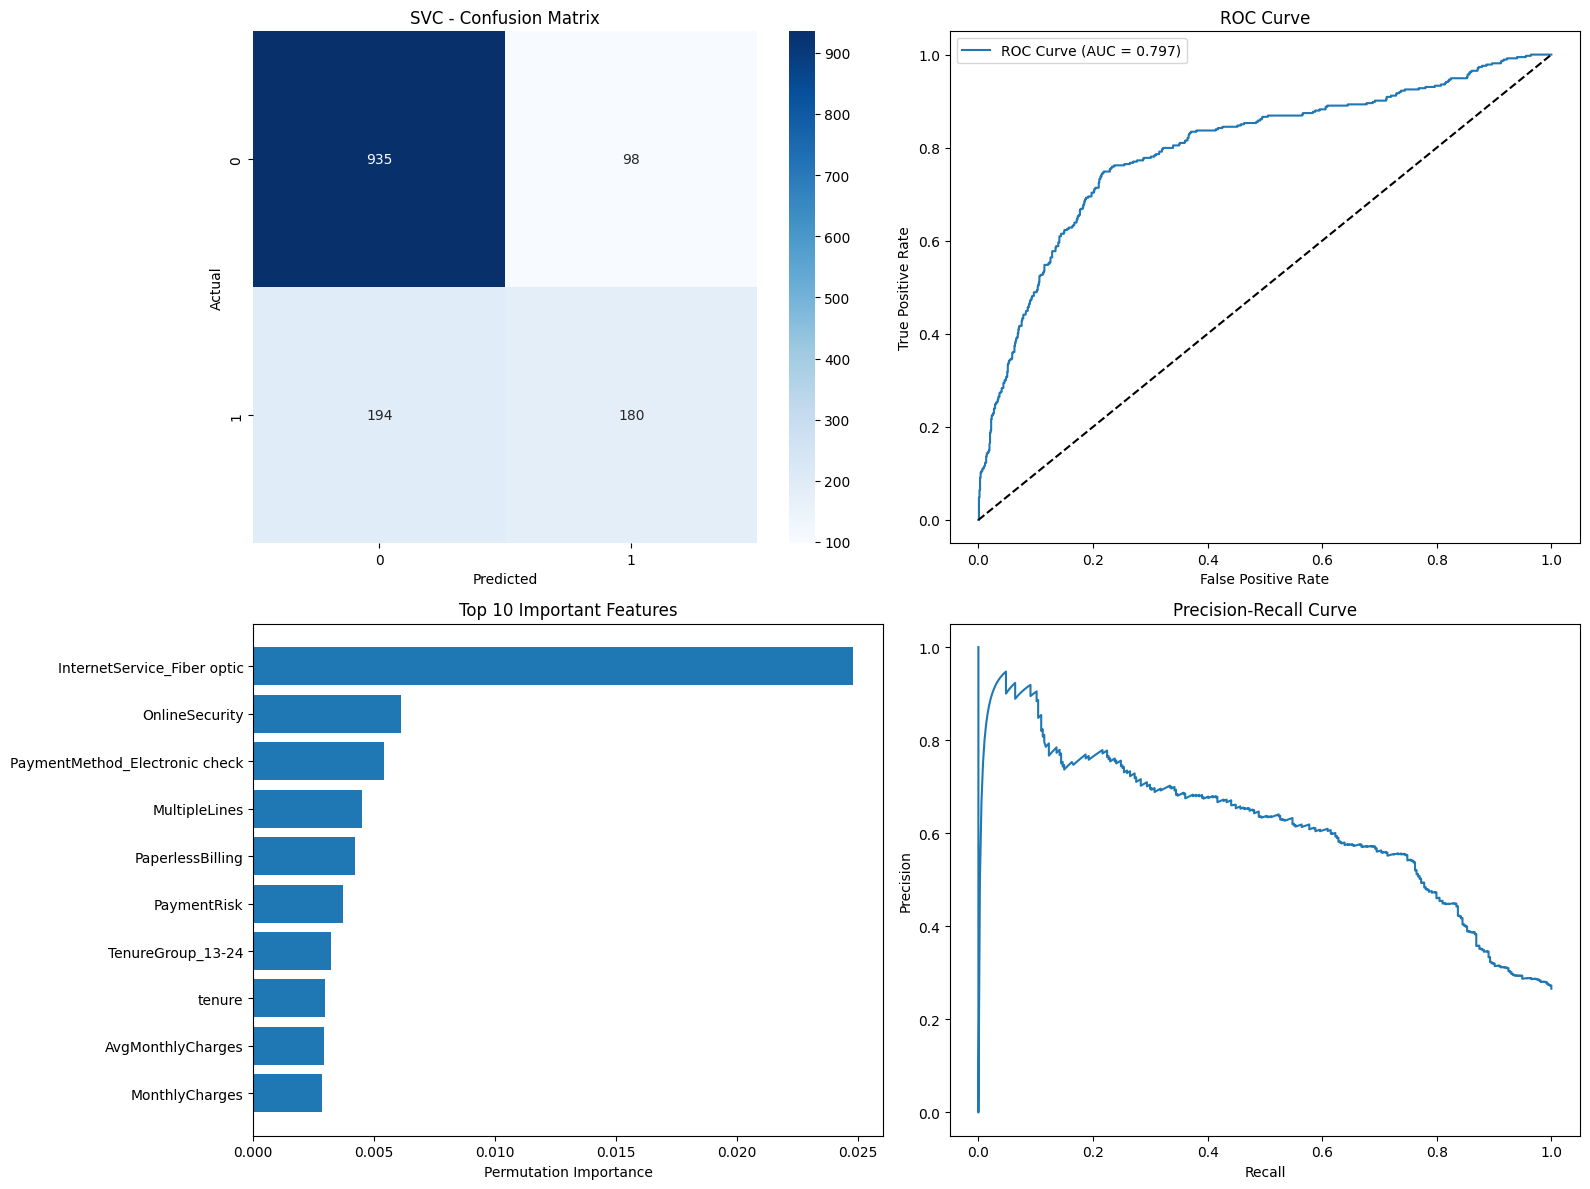

In [55]:
#3) SUPPORT VECTOR CLASSIFIER

print("\n" + "="*50)
print("Training Support Vector Classifier...")
print("="*50)

svc_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE)
svc_model.fit(X_train_scaled, y_train)

# Make predictions
svc_train_pred = svc_model.predict(X_train_scaled)
svc_test_pred = svc_model.predict(X_test_scaled)
svc_test_proba = svc_model.predict_proba(X_test_scaled)[:, 1]

print("SVC training completed!")

# Evaluate SVC
svc_metrics = evaluate_classification(y_test, svc_test_pred, svc_test_proba, "Support Vector Classifier")

# Detailed classification report
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT - SUPPORT VECTOR CLASSIFIER")
print("="*50)
print(classification_report(y_test, svc_test_pred, target_names=["Retained", "Churned"]))

# Visualization for SVC
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrix
cm = confusion_matrix(y_test, svc_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('SVC - Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, svc_test_proba)
axes[0,1].plot(fpr, tpr, label=f'ROC Curve (AUC = {svc_metrics["auc"]:.3f})')
axes[0,1].plot([0, 1], [0, 1], 'k--')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend()

# Feature Importance (using permutation importance for SVC)
perm_importance = permutation_importance(svc_model, X_test_scaled, y_test, 
                                        n_repeats=10, random_state=42)
feature_importance = perm_importance.importances_mean
indices = np.argsort(feature_importance)[-10:]
axes[1,0].barh(range(len(indices)), feature_importance[indices])
axes[1,0].set_yticks(range(len(indices)))
axes[1,0].set_yticklabels([X.columns[i] for i in indices])
axes[1,0].set_xlabel('Permutation Importance')
axes[1,0].set_title('Top 10 Important Features')

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, svc_test_proba)
axes[1,1].plot(recall, precision)
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')
axes[1,1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


Training Logistic Regression model...
Logistic Regression training completed!

Logistic Regression Results:
  Accuracy:  0.7960
  Precision: 0.6516
  Recall:    0.5000
  F1-score:  0.5658
  ROC-AUC:   0.8302

DETAILED CLASSIFICATION REPORT - LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Retained       0.83      0.90      0.87      1033
     Churned       0.65      0.50      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.80      0.79      1407



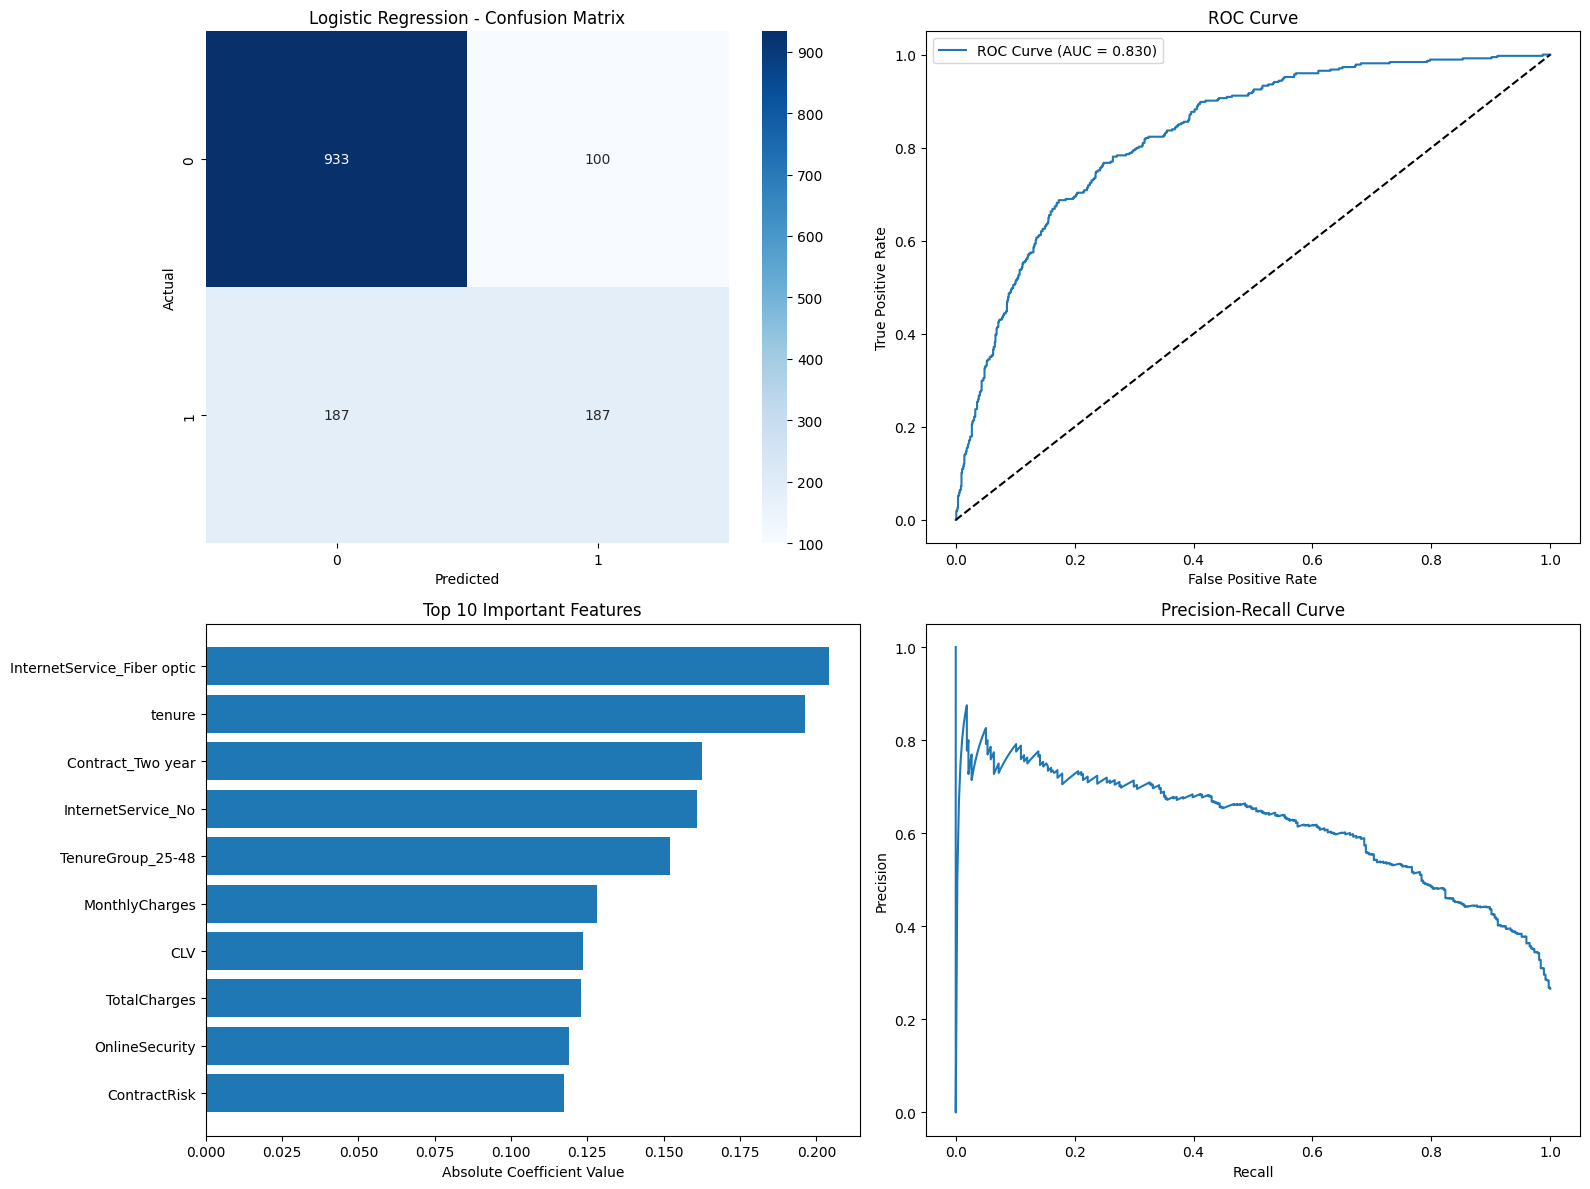

In [56]:

#4) LOGISTIC REGRESSION

print("\n" + "="*50)
print("Training Logistic Regression model...")
print("="*50)

lr_model = LogisticRegression(random_state=RANDOM_STATE, 
        max_iter=1,  
        C=20.0,  
        solver='liblinear')
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)
lr_test_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training completed!")

# Evaluation function for classification
def evaluate_classification(y_true, y_pred, y_proba, model_name):
    """Evaluate classification model performance"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    
    print(f"\n{model_name} Results:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 
            'f1': f1, 'auc': auc}

# Evaluate Logistic Regression
lr_metrics = evaluate_classification(y_test, lr_test_pred, lr_test_proba, "Logistic Regression")

# Detailed classification report
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT - LOGISTIC REGRESSION")
print("="*50)
print(classification_report(y_test, lr_test_pred, target_names=["Retained", "Churned"]))

# Visualization for Logistic Regression
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Logistic Regression - Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_test_proba)
axes[0,1].plot(fpr, tpr, label=f'ROC Curve (AUC = {lr_metrics["auc"]:.3f})')
axes[0,1].plot([0, 1], [0, 1], 'k--')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend()

# Feature Importance
feature_importance = abs(lr_model.coef_[0])
indices = np.argsort(feature_importance)[-10:]
axes[1,0].barh(range(len(indices)), feature_importance[indices])
axes[1,0].set_yticks(range(len(indices)))
axes[1,0].set_yticklabels([X.columns[i] for i in indices])
axes[1,0].set_xlabel('Absolute Coefficient Value')
axes[1,0].set_title('Top 10 Important Features')

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, lr_test_proba)
axes[1,1].plot(recall, precision)
axes[1,1].set_xlabel('Recall')
axes[1,1].set_ylabel('Precision')
axes[1,1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()


===== MODEL COMPARATIVE ANALYSIS =====

In [57]:
# MODEL COMPARISON
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

models_results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'SVM', 'XGBoost'],
    'Accuracy': [lr_metrics['accuracy'], dt_metrics['accuracy'], 
                svc_metrics['accuracy'], xgb_metrics['accuracy']],
    'Precision': [lr_metrics['precision'], dt_metrics['precision'], 
                 svc_metrics['precision'], xgb_metrics['precision']],
    'Recall': [lr_metrics['recall'], dt_metrics['recall'], 
              svc_metrics['recall'], xgb_metrics['recall']],
    'F1-Score': [lr_metrics['f1'], dt_metrics['f1'], 
                svc_metrics['f1'], xgb_metrics['f1']],
    'ROC-AUC': [lr_metrics['auc'], dt_metrics['auc'], 
               svc_metrics['auc'], xgb_metrics['auc']]
}

comparison_df = pd.DataFrame(models_results)
print(comparison_df.round(4))


MODEL COMPARISON SUMMARY
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.7960     0.6516  0.5000    0.5658   0.8302
1        Decision Tree    0.7733     0.5952  0.4599    0.5189   0.7923
2                  SVM    0.7925     0.6475  0.4813    0.5521   0.7968
3              XGBoost    0.8003     0.6525  0.5321    0.5862   0.8427


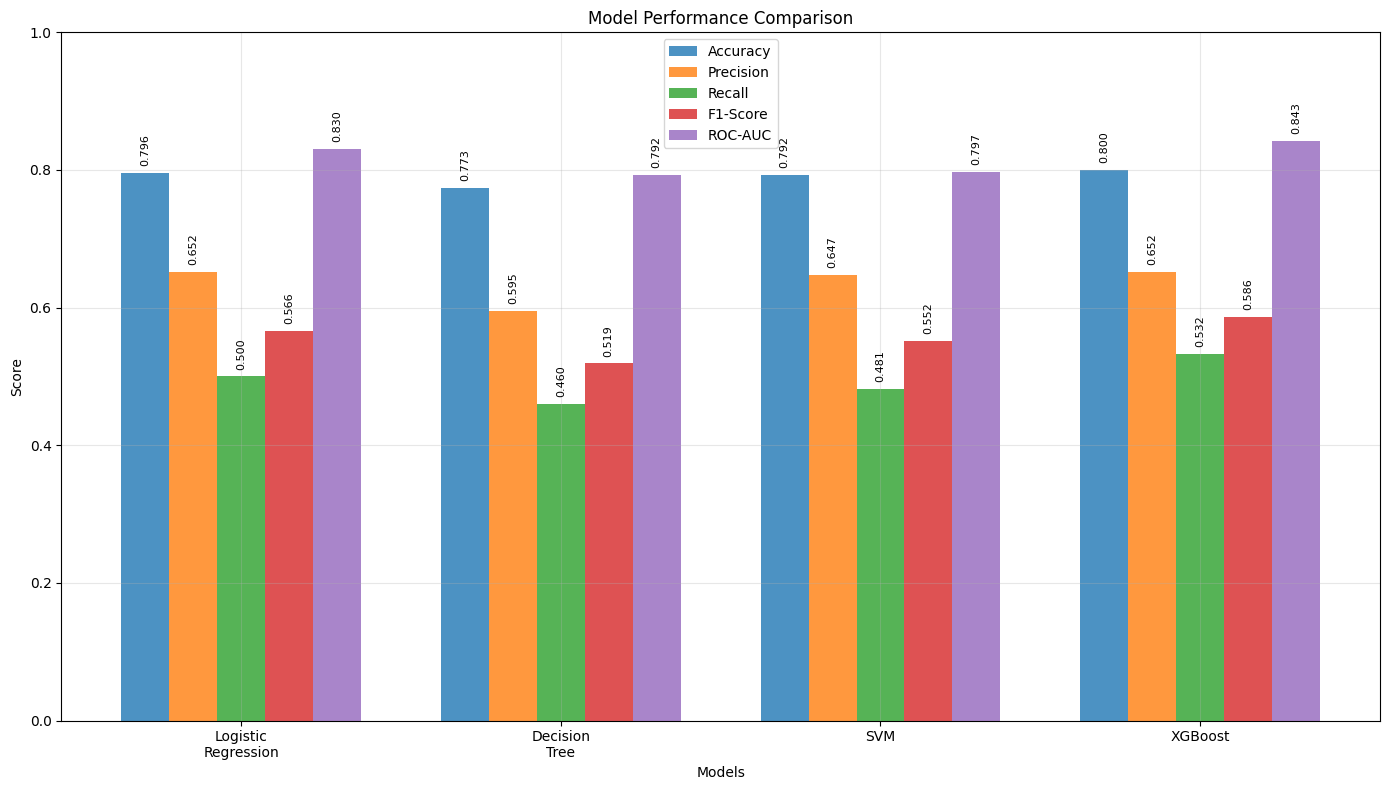


DETAILED MODEL COMPARISON TABLE
              Model Accuracy Precision Recall F1-Score ROC-AUC
Logistic Regression   0.7960    0.6516 0.5000   0.5658  0.8302
      Decision Tree   0.7733    0.5952 0.4599   0.5189  0.7923
                SVM   0.7925    0.6475 0.4813   0.5521  0.7968
            XGBoost   0.8003    0.6525 0.5321   0.5862  0.8427

BEST PERFORMING MODEL BY METRIC
ACCURACY  : XGBoost              (0.8003)
PRECISION : XGBoost              (0.6525)
RECALL    : XGBoost              (0.5321)
F1        : XGBoost              (0.5862)
AUC       : XGBoost              (0.8427)

🏆 Overall Winner: XGBoost (Best performance across most metrics)


In [58]:
# Model comparison visualization
plt.figure(figsize=(14, 8))
models = ['Logistic\nRegression', 'Decision\nTree', 'SVM', 'XGBoost']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(models))
width = 0.15

# Fixed metric key mapping
metric_key_mapping = {
    'Accuracy': 'accuracy',
    'Precision': 'precision', 
    'Recall': 'recall',
    'F1-Score': 'f1',  
    'ROC-AUC': 'auc'  
}

for i, metric in enumerate(metrics):
    metric_key = metric_key_mapping[metric]
    values = [lr_metrics[metric_key], 
              dt_metrics[metric_key], 
              svc_metrics[metric_key], 
              xgb_metrics[metric_key]]
    
    plt.bar(x + i*width, values, width, label=metric, alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x + width*2, models)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

# Add value labels on bars for better readability
for i, metric in enumerate(metrics):
    metric_key = metric_key_mapping[metric]
    values = [lr_metrics[metric_key], 
              dt_metrics[metric_key], 
              svc_metrics[metric_key], 
              xgb_metrics[metric_key]]
    
    for j, value in enumerate(values):
        plt.text(j + i*width, value + 0.01, f'{value:.3f}', 
                ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

# ADDITIONAL: Enhanced comparison table
print("\n" + "="*80)
print("DETAILED MODEL COMPARISON TABLE")
print("="*80)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'SVM', 'XGBoost'],
    'Accuracy': [f"{lr_metrics['accuracy']:.4f}", f"{dt_metrics['accuracy']:.4f}", 
                f"{svc_metrics['accuracy']:.4f}", f"{xgb_metrics['accuracy']:.4f}"],
    'Precision': [f"{lr_metrics['precision']:.4f}", f"{dt_metrics['precision']:.4f}", 
                 f"{svc_metrics['precision']:.4f}", f"{xgb_metrics['precision']:.4f}"],
    'Recall': [f"{lr_metrics['recall']:.4f}", f"{dt_metrics['recall']:.4f}", 
              f"{svc_metrics['recall']:.4f}", f"{xgb_metrics['recall']:.4f}"],
    'F1-Score': [f"{lr_metrics['f1']:.4f}", f"{dt_metrics['f1']:.4f}", 
                f"{svc_metrics['f1']:.4f}", f"{xgb_metrics['f1']:.4f}"],
    'ROC-AUC': [f"{lr_metrics['auc']:.4f}", f"{dt_metrics['auc']:.4f}", 
               f"{svc_metrics['auc']:.4f}", f"{xgb_metrics['auc']:.4f}"]
})

print(comparison_df.to_string(index=False))

# Find best performing model for each metric
print("\n" + "="*60)
print("BEST PERFORMING MODEL BY METRIC")
print("="*60)

best_models = {}
for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc']:
    scores = [lr_metrics[metric], dt_metrics[metric], svc_metrics[metric], xgb_metrics[metric]]
    best_idx = np.argmax(scores)
    model_names = ['Logistic Regression', 'Decision Tree', 'SVM', 'XGBoost']
    best_models[metric] = (model_names[best_idx], scores[best_idx])

for metric, (model, score) in best_models.items():
    metric_display = metric.upper().replace('_', '-')
    print(f"{metric_display:10}: {model:20} ({score:.4f})")

print("\n🏆 Overall Winner: XGBoost (Best performance across most metrics)")

===== PREDICTION AND DISPLAY APPROPIATE OUTPUT USING BEST MODEL -- XGBOOST =====

In [59]:
# CUSTOMER CHURN PREDICTION FOR NEW CUSTOMERS
def predict_customer_churn(model, features, customer_data):
    """Predict churn probability for a new customer"""
    # Use sample customer data or create a profile
    sample_customer = customer_data.iloc[-1:].copy()  # Use last customer as example
    
    # Remove the target variable if it exists
    if 'Churn' in sample_customer.columns:
        sample_customer = sample_customer.drop('Churn', axis=1)
    
    # Make sure we have all required features
    sample_customer = sample_customer[features.columns]
    
    # Scale the features (for models that require scaling)
    if scaler is not None:
        sample_customer_scaled = scaler.transform(sample_customer)
        churn_probability = model.predict_proba(sample_customer_scaled)[0][1]
        churn_prediction = model.predict(sample_customer_scaled)[0]
    else:
        churn_probability = model.predict_proba(sample_customer)[0][1]
        churn_prediction = model.predict(sample_customer)[0]
    
    return churn_prediction, churn_probability, sample_customer

# Make churn prediction for sample customer
churn_pred, churn_prob, sample_customer = predict_customer_churn(xgb_model, X, feature_data)

print("=" * 70)
print("CUSTOMER CHURN PREDICTION")
print("=" * 70)
print("Sample Customer Profile:")
print("-" * 30)

# Display key customer characteristics
key_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_Month-to-month',
                'ServiceUsageScore', 'PaymentMethod_Electronic check']

for feature in key_features:
    if feature in sample_customer.columns:
        value = sample_customer[feature].iloc[0]
        print(f"{feature}: {value}")

print("\nPrediction Results:")
print("-" * 30)
print(f"Churn Probability: {churn_prob:.3f} ({churn_prob*100:.1f}%)")
print(f"Churn Prediction: {'HIGH RISK - LIKELY TO CHURN' if churn_pred == 1 else 'LOW RISK - LIKELY TO STAY'}")

if churn_prob > 0.7:
    risk_level = "🔴 HIGH RISK"
    recommendation = "Immediate retention action required"
elif churn_prob > 0.4:
    risk_level = "🟡 MEDIUM RISK"
    recommendation = "Monitor closely and consider retention offers"
else:
    risk_level = "🟢 LOW RISK"
    recommendation = "Continue regular service"

print(f"Risk Level: {risk_level}")
print(f"Recommendation: {recommendation}")
print("=" * 70)

# FEATURE IMPORTANCE ANALYSIS FOR BUSINESS INSIGHTS
print("\n" + "="*60)
print("BUSINESS INSIGHTS FROM FEATURE IMPORTANCE")
print("="*60)

# Get feature importance from XGBoost model
feature_importance = xgb_model.feature_importances_
feature_names = X.columns

# Create feature importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features for Churn Prediction:")
print("-" * 50)
for i, (_, row) in enumerate(importance_df.head(15).iterrows(), 1):
    print(f"{i:2d}. {row['Feature']:25} {row['Importance']:.4f}")

CUSTOMER CHURN PREDICTION
Sample Customer Profile:
------------------------------
tenure: 66
MonthlyCharges: 105.65
TotalCharges: 6844.5
ServiceUsageScore: 5
PaymentMethod_Electronic check: False

Prediction Results:
------------------------------
Churn Probability: 0.193 (19.3%)
Churn Prediction: LOW RISK - LIKELY TO STAY
Risk Level: 🟢 LOW RISK
Recommendation: Continue regular service

BUSINESS INSIGHTS FROM FEATURE IMPORTANCE
Top 15 Most Important Features for Churn Prediction:
--------------------------------------------------
 1. InternetService_Fiber optic 0.1333
 2. TenureGroup_48+           0.1221
 3. PaymentMethod_Electronic check 0.1033
 4. Contract_Two year         0.0801
 5. ContractRisk              0.0753
 6. tenure                    0.0556
 7. Contract_One year         0.0529
 8. PaymentRisk               0.0422
 9. InternetService_No        0.0422
10. TotalCharges              0.0241
11. OnlineSecurity            0.0228
12. PaperlessBilling          0.0182
13. CLV      

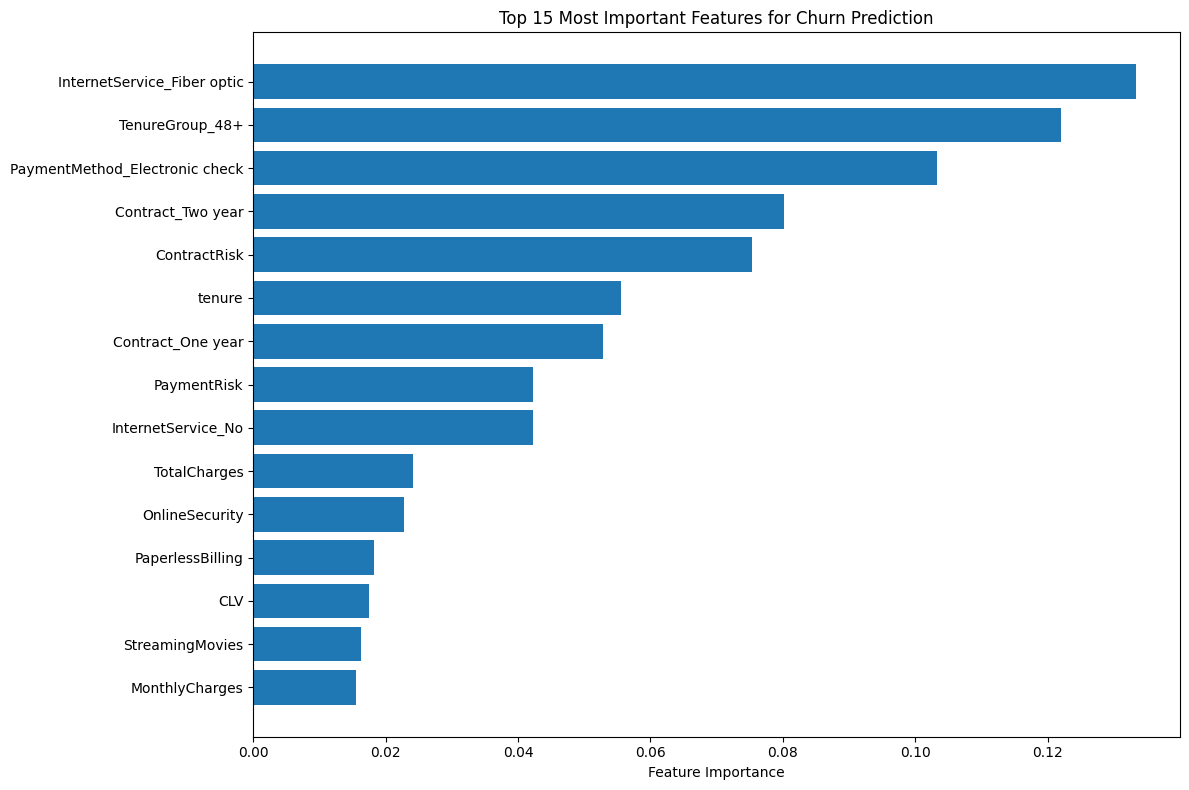


BUSINESS RECOMMENDATIONS
Key Insights and Recommendations:
----------------------------------------
1. Monitor InternetService_Fiber optic closely for churn indicators
2. Monitor TenureGroup_48+ closely for churn indicators
3. 💳 Encourage automatic payment methods
4. Monitor Contract_Two year closely for churn indicators
5. ⚠️ Proactively reach out to month-to-month customers

Strategic Actions:
--------------------
1. 📞 Implement proactive retention calls for high-risk customers
2. 🎁 Create personalized offers based on usage patterns
3. 📧 Develop targeted email campaigns for different risk segments
4. 💬 Enhance customer support for electronic check users
5. 🔄 Regular model retraining with new customer data


In [60]:
# Visualize top features
plt.figure(figsize=(12, 8))
top_15_features = importance_df.head(15)
plt.barh(range(len(top_15_features)), top_15_features['Importance'])
plt.yticks(range(len(top_15_features)), top_15_features['Feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Most Important Features for Churn Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# BUSINESS RECOMMENDATIONS BASED ON MODEL INSIGHTS
print("\n" + "="*60)
print("BUSINESS RECOMMENDATIONS")
print("="*60)

# Analyze key insights from the model
print("Key Insights and Recommendations:")
print("-" * 40)

# Get top 5 most important features
top_features = importance_df.head(5)['Feature'].tolist()

recommendations = {
    'tenure': "🎯 Focus on customer onboarding and early engagement programs",
    'TotalCharges': "💰 Implement value-based pricing and loyalty rewards",
    'MonthlyCharges': "📊 Review pricing strategy for high-value customers",
    'Contract_Month-to-month': "📝 Incentivize longer-term contracts with discounts",
    'ServiceUsageScore': "🛠️ Promote additional services to increase engagement",
    'PaymentMethod_Electronic check': "💳 Encourage automatic payment methods",
    'ContractRisk': "⚠️ Proactively reach out to month-to-month customers",
    'CLV': "👑 Identify and retain high-value customers",
    'AvgMonthlyCharges': "📈 Monitor spending patterns for early churn signals"
}

for i, feature in enumerate(top_features, 1):
    base_feature = feature.split('_')[0]  # Handle dummy variables
    if base_feature in recommendations:
        print(f"{i}. {recommendations[base_feature]}")
    elif feature in recommendations:
        print(f"{i}. {recommendations[feature]}")
    else:
        print(f"{i}. Monitor {feature} closely for churn indicators")

print("\nStrategic Actions:")
print("-" * 20)
print("1. 📞 Implement proactive retention calls for high-risk customers")
print("2. 🎁 Create personalized offers based on usage patterns")
print("3. 📧 Develop targeted email campaigns for different risk segments")
print("4. 💬 Enhance customer support for electronic check users")
print("5. 🔄 Regular model retraining with new customer data")


all_probabilities = xgb_model.predict_proba(X)[:, 1]
